In [2]:
# Install any missing packages (uncomment if needed)
# !pip install -q pandas numpy matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn # Add this line to import the top-level sklearn module
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set professional visualization defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Display versions
print("="*50)
print("LIBRARY VERSIONS")
print("="*50)
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print("="*50)
print("Analysis session started!")

LIBRARY VERSIONS
Pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
Seaborn: 0.13.2
Scikit-learn: 1.6.1
Analysis session started!


In [3]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)

# Rename the target column
df.rename(columns={'default payment next month': 'Default'}, inplace=True)

# Display basic information
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

print("\n" + "="*60)
print("COLUMN DESCRIPTIONS")
print("="*60)

column_descriptions = {
    'ID': 'Client identification number',
    'LIMIT_BAL': 'Credit limit amount (NT dollars)',
    'SEX': 'Gender (1=male, 2=female)',
    'EDUCATION': 'Education level (1=graduate school, 2=university, 3=high school, 4=others)',
    'MARRIAGE': 'Marital status (1=married, 2=single, 3=others)',
    'AGE': 'Age in years',
    'PAY_0': 'Repayment status in September (0=pay duly, 1=delay 1 month, 2=delay 2 months, etc.)',
    'PAY_2': 'Repayment status in August',
    'PAY_3': 'Repayment status in July',
    'PAY_4': 'Repayment status in June',
    'PAY_5': 'Repayment status in May',
    'PAY_6': 'Repayment status in April',
    'BILL_AMT1': 'Bill statement amount in September (NT dollars)',
    'BILL_AMT2': 'Bill statement amount in August',
    'BILL_AMT3': 'Bill statement amount in July',
    'BILL_AMT4': 'Bill statement amount in June',
    'BILL_AMT5': 'Bill statement amount in May',
    'BILL_AMT6': 'Bill statement amount in April',
    'PAY_AMT1': 'Payment amount in September (NT dollars)',
    'PAY_AMT2': 'Payment amount in August',
    'PAY_AMT3': 'Payment amount in July',
    'PAY_AMT4': 'Payment amount in June',
    'PAY_AMT5': 'Payment amount in May',
    'PAY_AMT6': 'Payment amount in April',
    'Default': 'Default status (1=defaulted, 0=did not default)'
}

for col in df.columns:
    print(f"\n{col}: {column_descriptions.get(col, 'Description not available')}")

print("\n" + "="*60)
print("DATA INFO")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(df.describe())

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(df.isnull().sum())

DATASET OVERVIEW
Dataset shape: 30000 rows × 25 columns

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PA

DEFAULT DISTRIBUTION AFTER CONVERSION
Default_Label
No Default    23364
Default        6636
Name: count, dtype: int64

Default rate: 22.12%


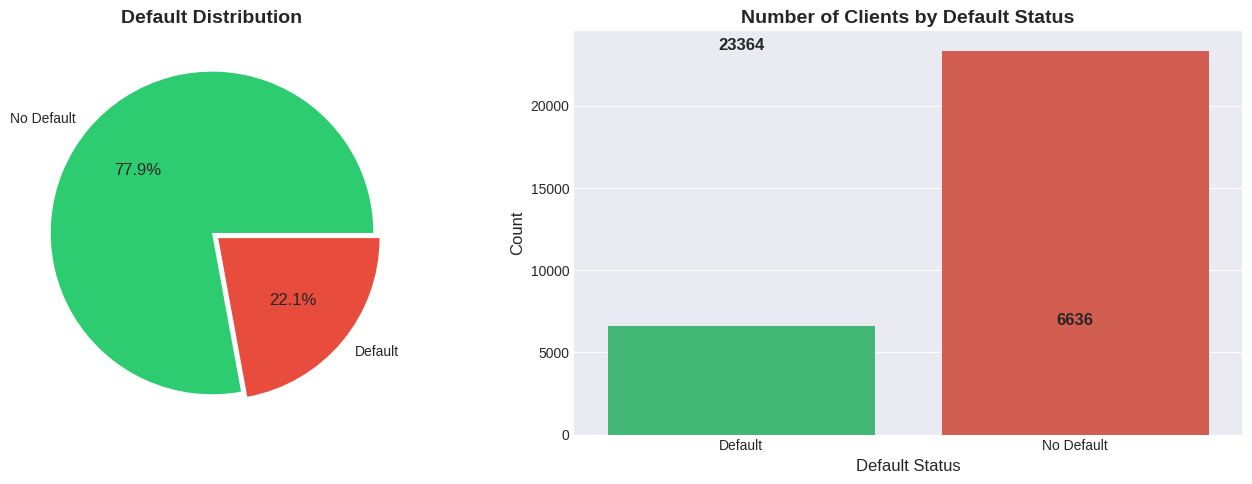


KEY CORRELATIONS WITH DEFAULT
Default      1.000000
EDUCATION    0.028006
AGE          0.013890
MARRIAGE    -0.024339
SEX         -0.039961
LIMIT_BAL   -0.153520
Name: Default, dtype: float64


In [4]:
# Convert Default column to categorical with meaningful labels
df['Default_Label'] = df['Default'].map({0: 'No Default', 1: 'Default'})
df['Default_Label'] = df['Default_Label'].astype('category')

# Verify the conversion
print("="*60)
print("DEFAULT DISTRIBUTION AFTER CONVERSION")
print("="*60)
print(df['Default_Label'].value_counts())
print(f"\nDefault rate: {df['Default'].mean()*100:.2f}%")

# Create a simple visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
df['Default_Label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[0],
    colors=['#2ecc71', '#e74c3c'],
    explode=[0, 0.05]
)
axes[0].set_title('Default Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Count plot
sns.countplot(data=df, x='Default_Label', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Number of Clients by Default Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Default Status')
axes[1].set_ylabel('Count')
for i, v in enumerate(df['Default_Label'].value_counts()):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation matrix for key variables
print("\n" + "="*60)
print("KEY CORRELATIONS WITH DEFAULT")
print("="*60)
key_cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'Default']
correlation_matrix = df[key_cols].corr()
print(correlation_matrix['Default'].sort_values(ascending=False))

DECISION TREE MODEL
Training set size: 21000 samples
Test set size: 9000 samples
Default rate in training: 22.12%
Default rate in test: 22.12%

Model Accuracy: 77.41%

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.84      0.85      7009
     Default       0.49      0.55      0.52      1991

    accuracy                           0.77      9000
   macro avg       0.68      0.69      0.69      9000
weighted avg       0.78      0.77      0.78      9000



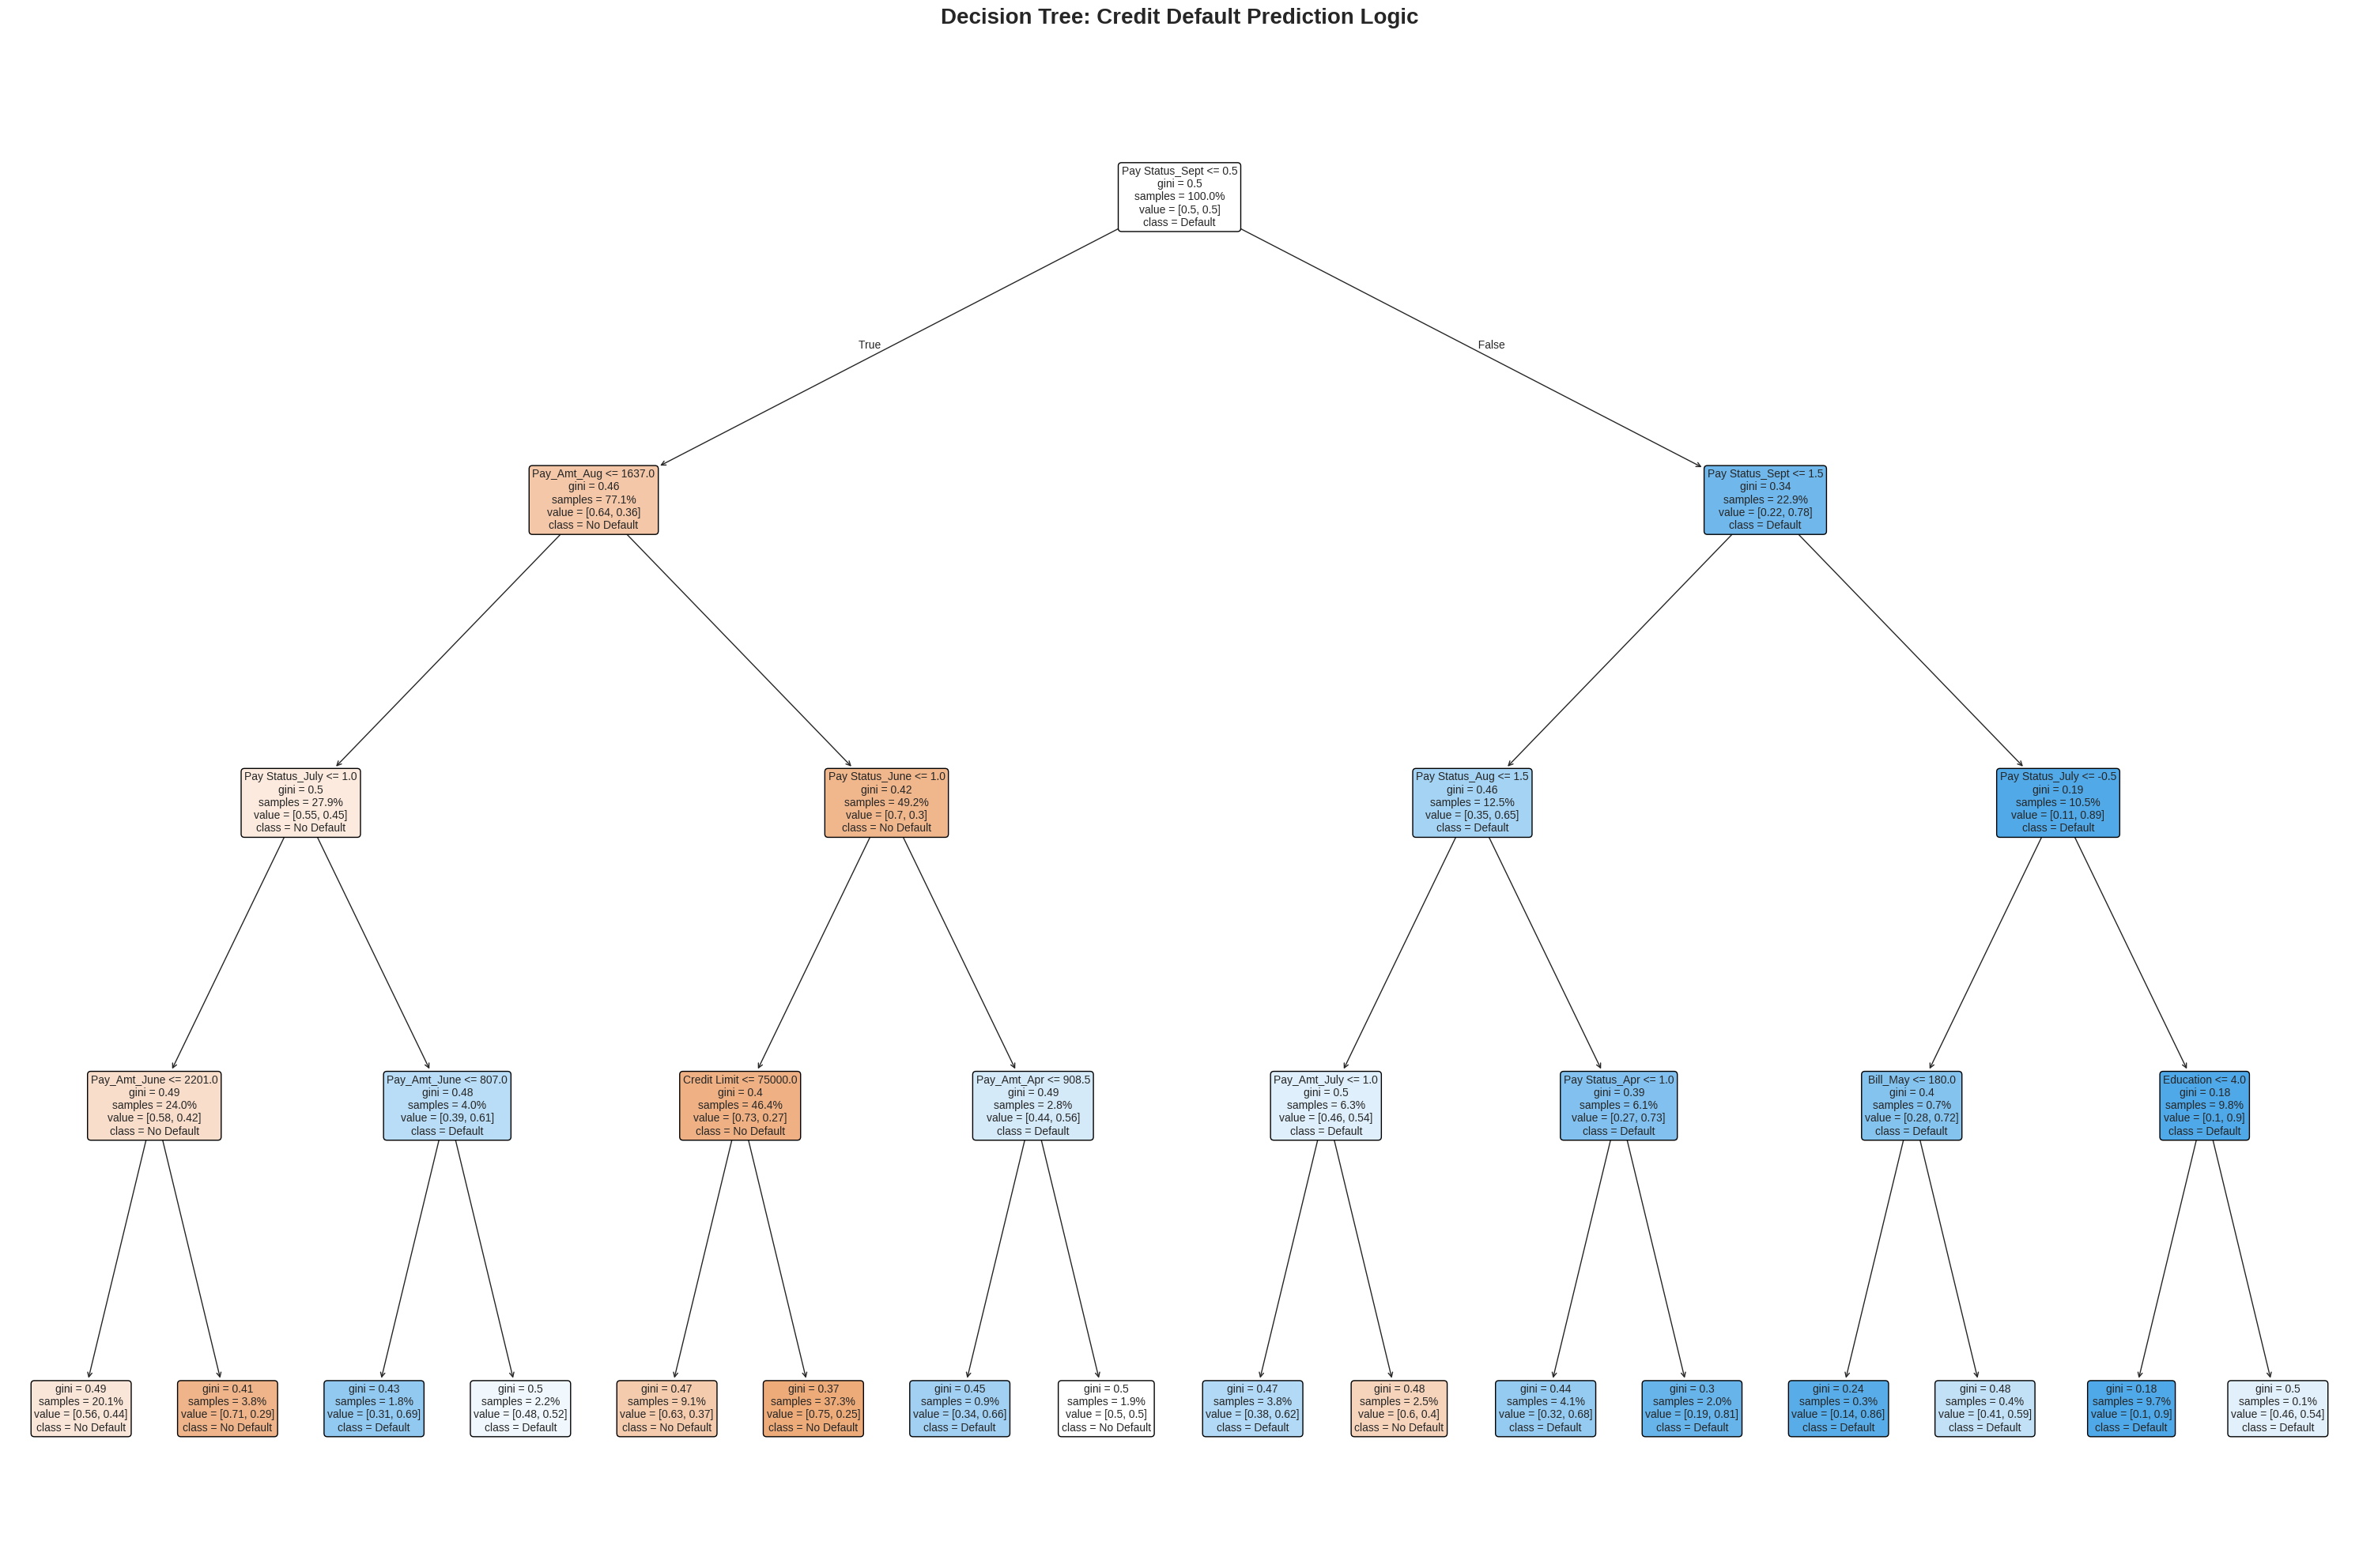


TOP 10 MOST IMPORTANT FEATURES (Decision Tree)
            Feature  Importance
5   Pay Status_Sept    0.781829
18      Pay_Amt_Aug    0.069737
8   Pay Status_June    0.039175
7   Pay Status_July    0.026624
6    Pay Status_Aug    0.022316
20     Pay_Amt_June    0.017271
0      Credit Limit    0.015738
19     Pay_Amt_July    0.013249
10   Pay Status_Apr    0.005942
22      Pay_Amt_Apr    0.003017


In [5]:
# Prepare features and target
X = df.drop(['Default', 'Default_Label', 'ID'], axis=1)
y = df['Default']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("="*60)
print("DECISION TREE MODEL")
print("="*60)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Default rate in training: {y_train.mean()*100:.2f}%")
print(f"Default rate in test: {y_test.mean()*100:.2f}%")

# Create and train decision tree
dt_model = DecisionTreeClassifier(
    max_depth=4,           # Limit depth for interpretability
    min_samples_split=50,  # Avoid overfitting
    min_samples_leaf=20,   # Ensure meaningful nodes
    random_state=42,
    class_weight='balanced'  # Handle imbalanced data
)
dt_model.fit(X_train, y_train)

# Evaluate
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# Create feature names with clearer descriptions
feature_names_clean = [
    'Credit Limit', 'Gender', 'Education', 'Marriage', 'Age',
    'Pay Status_Sept', 'Pay Status_Aug', 'Pay Status_July', 'Pay Status_June',
    'Pay Status_May', 'Pay Status_Apr', 'Bill_Sept', 'Bill_Aug', 'Bill_July',
    'Bill_June', 'Bill_May', 'Bill_Apr', 'Pay_Amt_Sept', 'Pay_Amt_Aug',
    'Pay_Amt_July', 'Pay_Amt_June', 'Pay_Amt_May', 'Pay_Amt_Apr'
]

# Visualize decision tree
plt.figure(figsize=(30, 20))
plot_tree(
    dt_model,
    feature_names=feature_names_clean,
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10,
    proportion=True,
    precision=2
)
plt.title('Decision Tree: Credit Default Prediction Logic', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('Decision_Tree_Visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature importance from decision tree
feature_importance = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES (Decision Tree)")
print("="*60)
print(feature_importance.head(10))

In [6]:
# Prepare data with scaling
X_scaled = X.copy()
scaler = StandardScaler()
numeric_cols = X_scaled.select_dtypes(include=[np.number]).columns
X_scaled[numeric_cols] = scaler.fit_transform(X_scaled[numeric_cols])

# Split scaled data
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Train logistic regression with balanced weights
logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    C=1.0  # Regularization strength
)
logreg_model.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = logreg_model.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("="*60)
print("LOGISTIC REGRESSION MODEL")
print("="*60)
print(f"Model Accuracy: {accuracy_lr*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default']))

# Create coefficients dataframe with interpretation
coef_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Coefficient': logreg_model.coef_[0],
    'Odds_Ratio': np.exp(logreg_model.coef_[0])
})

# Classify as Red Flag (increases default risk) or Green Flag (decreases default risk)
coef_df['Impact'] = coef_df['Coefficient'].apply(
    lambda x: '🔴 RED FLAG (Increases Default Risk)' if x > 0 else '🟢 GREEN FLAG (Decreases Default Risk)'
)

# Calculate absolute impact for sorting
coef_df['Abs_Impact'] = np.abs(coef_df['Coefficient'])

# Sort by absolute impact
coef_df = coef_df.sort_values('Abs_Impact', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("FACTOR ANALYSIS: RED FLAGS vs GREEN FLAGS")
print("="*80)

# Display with formatting
for idx, row in coef_df.iterrows():
    impact_color = "🔴" if row['Coefficient'] > 0 else "🟢"
    print(f"\n{impact_color} {row['Feature']}:")
    print(f"   Coefficient: {row['Coefficient']:.4f}")
    print(f"   Odds Ratio: {row['Odds_Ratio']:.4f}")
    print(f"   {row['Impact']}")

print("\n" + "="*80)
print("INTERPRETATION GUIDE")
print("="*80)
print("• Positive Coefficient (🔴) = Factor INCREASES probability of default")
print("• Negative Coefficient (🟢) = Factor DECREASES probability of default")
print("• Odds Ratio > 1 = Higher default risk; Odds Ratio < 1 = Lower default risk")

LOGISTIC REGRESSION MODEL
Model Accuracy: 68.38%

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.70      0.78      7009
     Default       0.37      0.63      0.47      1991

    accuracy                           0.68      9000
   macro avg       0.62      0.66      0.62      9000
weighted avg       0.76      0.68      0.71      9000


FACTOR ANALYSIS: RED FLAGS vs GREEN FLAGS

🔴 Pay Status_Sept:
   Coefficient: 0.5829
   Odds Ratio: 1.7913
   🔴 RED FLAG (Increases Default Risk)

🟢 Bill_Sept:
   Coefficient: -0.2818
   Odds Ratio: 0.7544
   🟢 GREEN FLAG (Decreases Default Risk)

🟢 Pay_Amt_Aug:
   Coefficient: -0.2621
   Odds Ratio: 0.7694
   🟢 GREEN FLAG (Decreases Default Risk)

🟢 Pay_Amt_Sept:
   Coefficient: -0.1399
   Odds Ratio: 0.8695
   🟢 GREEN FLAG (Decreases Default Risk)

🟢 Credit Limit:
   Coefficient: -0.1183
   Odds Ratio: 0.8884
   🟢 GREEN FLAG (Decreases Default Risk)

🔴 Pay Status_Aug:
   Coefficient: 0.1110

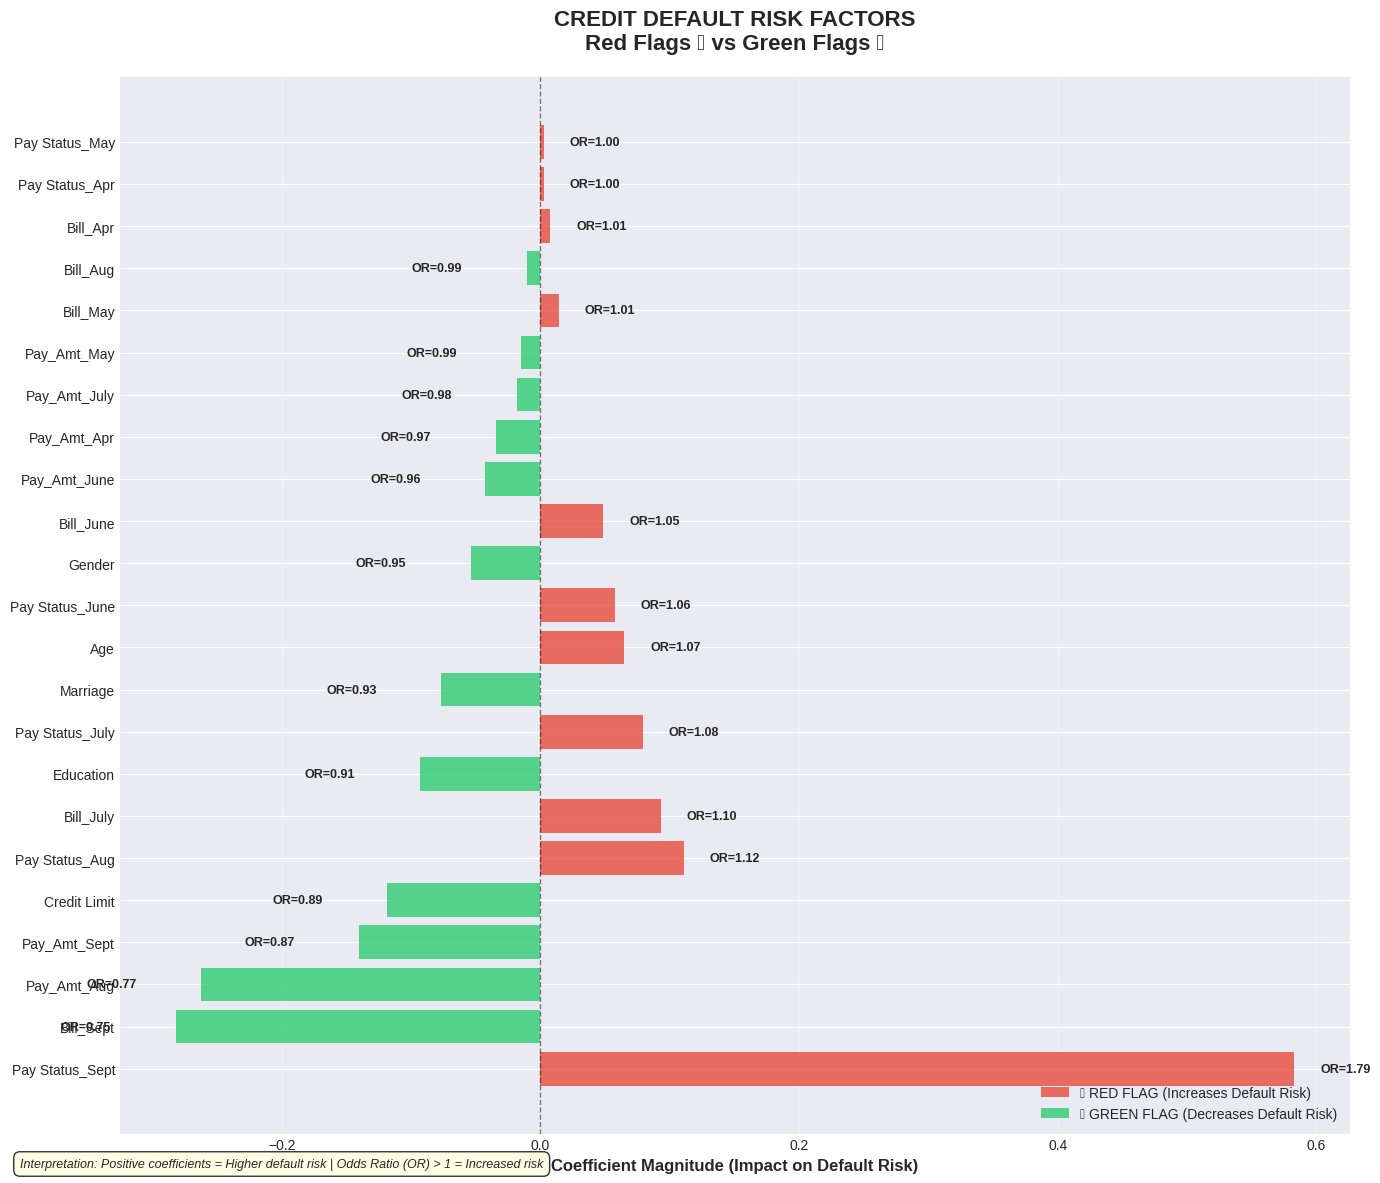


TOP 5 RISK FACTORS (RED FLAGS)
Pay Status_Sept: Odds Ratio = 1.791
Pay Status_Aug: Odds Ratio = 1.117
Bill_July: Odds Ratio = 1.098
Pay Status_July: Odds Ratio = 1.082
Age: Odds Ratio = 1.067

TOP 5 PROTECTIVE FACTORS (GREEN FLAGS)
Pay_Amt_June: Odds Ratio = 0.958
Pay_Amt_Apr: Odds Ratio = 0.966
Pay_Amt_July: Odds Ratio = 0.982
Pay_Amt_May: Odds Ratio = 0.985
Bill_Aug: Odds Ratio = 0.990


In [7]:
# Prepare data for visualization
# Separate red and green flags
red_flags = coef_df[coef_df['Coefficient'] > 0].sort_values('Coefficient', ascending=True)
green_flags = coef_df[coef_df['Coefficient'] < 0].sort_values('Coefficient', ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(14, 12))

# Create color mapping
colors = ['#e74c3c' if coef > 0 else '#2ecc71' for coef in coef_df['Coefficient']]

# Create horizontal bar chart
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.8)

# Add zero line
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Add value labels
for i, (bar, coef, odds) in enumerate(zip(bars, coef_df['Coefficient'], coef_df['Odds_Ratio'])):
    if coef > 0:
        ax.text(coef + 0.02, bar.get_y() + bar.get_height()/2,
                f'OR={odds:.2f}', va='center', fontsize=9, fontweight='bold')
    else:
        ax.text(coef - 0.05, bar.get_y() + bar.get_height()/2,
                f'OR={odds:.2f}', va='center', ha='right', fontsize=9, fontweight='bold')

# Customize chart
ax.set_xlabel('Coefficient Magnitude (Impact on Default Risk)', fontsize=12, fontweight='bold')
ax.set_title('CREDIT DEFAULT RISK FACTORS\nRed Flags 🔴 vs Green Flags 🟢',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', alpha=0.8, label='🔴 RED FLAG (Increases Default Risk)'),
    Patch(facecolor='#2ecc71', alpha=0.8, label='🟢 GREEN FLAG (Decreases Default Risk)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Add interpretation note
plt.figtext(0.02, 0.02,
            "Interpretation: Positive coefficients = Higher default risk | Odds Ratio (OR) > 1 = Increased risk",
            fontsize=9, style='italic', bbox=dict(boxstyle="round,pad=0.5", facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('Credit_Default_Risk_Factors.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary statistics
print("\n" + "="*60)
print("TOP 5 RISK FACTORS (RED FLAGS)")
print("="*60)
top_red = coef_df[coef_df['Coefficient'] > 0].head(5)
for idx, row in top_red.iterrows():
    print(f"{row['Feature']}: Odds Ratio = {row['Odds_Ratio']:.3f}")

print("\n" + "="*60)
print("TOP 5 PROTECTIVE FACTORS (GREEN FLAGS)")
print("="*60)
top_green = coef_df[coef_df['Coefficient'] < 0].tail(5)
for idx, row in top_green.iterrows():
    print(f"{row['Feature']}: Odds Ratio = {row['Odds_Ratio']:.3f}")

## Phase 7: Interpreting the Results

### Executive Summary: Credit Default Risk Analysis

This analysis leverages a credit dataset to identify key drivers of default risk and evaluate the efficacy of predictive models for credit decision-making. We have employed both Decision Tree and Logistic Regression models, with a particular focus on the latter for its interpretability in identifying 'Red Flag' and 'Green Flag' factors.

### Preprocessing Steps Undertaken:

1.  **Data Acquisition:** The dataset was loaded from the UCI Machine Learning Repository.
2.  **Target Variable Refinement:** The original target column, 'default payment next month,' was renamed to 'Default' for enhanced clarity.
3.  **Categorical Conversion:** A new categorical column, 'Default_Label,' was derived from 'Default' to improve data visualization and readability.
4.  **Feature and Target Separation:** The dataset was partitioned into features (X) and the target variable (y), with the 'ID' column and 'Default_Label' being excluded from features.
5.  **Data Stratification and Splitting:** The data was divided into training (70%) and testing (30%) sets, ensuring the proportional representation of default cases through stratification.
6.  **Feature Scaling:** For the Logistic Regression model, all numerical features were scaled using `StandardScaler` to standardize their range, a critical step for algorithms sensitive to feature magnitudes.

### Analysis of Credit Default Risk Factors:

Based on the Logistic Regression model's coefficients, we can discern factors that significantly increase or decrease the probability of default:

*   **Biggest 'Red Flag':** The most impactful 'Red Flag' identified is **'Pay Status_Sept'** (repayment status in September). With an Odds Ratio of approximately **1.79**, a negative repayment status in September significantly increases the likelihood of a client defaulting. This indicates that recent payment behavior is a strong and immediate indicator of future default risk.

### Would you trust this model to deny credit? Why or why not?

The current Logistic Regression model, despite its interpretability, presents significant limitations for direct application in credit denial decisions:

*   **Model Accuracy & Precision:** The model achieves an overall accuracy of approximately **68.38%**. More critically, its **precision for identifying defaulting clients stands at a low 37%**. This implies that for every 100 clients the model predicts will default, only 37 actually do, leading to 63 false positives.

*   **Business Implications of Low Precision:** A high rate of false positives (incorrectly denying credit to creditworthy individuals) carries substantial business risks. It can lead to:
    *   **Lost Revenue:** Denying credit to good customers means forfeiture of potential interest income and transaction fees.
    *   **Customer Dissatisfaction:** Erroneous denials can damage customer relationships and lead to reputational harm.
    *   **Regulatory Scrutiny:** Unjustified denials can raise concerns about fairness and potentially lead to regulatory investigations.

*   **Recall for Defaulting Clients:** The model's recall for defaulting clients is approximately **63%**, meaning it correctly identifies 63% of actual defaulters. While reasonable, the low precision outweighs this in the context of credit denial.

**Conclusion on Trustworthiness:** Given the current model's **unacceptably low precision (37%) for predicting default**, it **should not be trusted to unilaterally deny credit**. The risk of incorrectly rejecting creditworthy applicants is too high, potentially leading to substantial financial losses and irreparable damage to customer trust.

### Recommendations:

1.  **Strategic Focus on Early Delinquency:** Given the prominence of 'Pay Status_Sept' as a 'Red Flag,' implement an aggressive early intervention strategy for clients exhibiting any payment delays in recent months. This could include automated alerts, personalized financial counseling, or proactive adjustment of credit limits to mitigate escalating risk.

2.  **Model Enhancement and Integrated Decision-Making:** To improve the reliability of credit risk assessment, I recommend the following steps:
    *   **Advanced Feature Engineering:** Explore richer feature sets, including interaction terms, longer-term payment trends, and potentially external data sources.
    *   **Evaluation of Alternative Models:** Investigate more robust machine learning algorithms, such as Gradient Boosting Machines (GBM) or Neural Networks, which might capture more complex patterns in the data.
    *   **Cost-Sensitive Learning:** Incorporate the differential costs of false positives (denying a good customer) versus false negatives (approving a bad customer) into the model's training objective.
    *   **Human-in-the-Loop System:** For all credit denial decisions, especially those flagged by the model, integrate a human review process. This allows for qualitative assessment and ensures fairness, particularly where the model's confidence is low.

### Conclusion:

While our initial models provide foundational insights into credit default drivers, their current predictive capabilities, particularly in terms of precision, are not yet suitable for autonomous credit denial. A multi-faceted approach combining targeted interventions based on identified risk factors with continuous model refinement and human oversight will be critical for building a robust, fair, and commercially viable credit risk management framework.

DEFAULT RATES BY DELINQUENCY CATEGORY
                      Default Rate  Count
Delinquency_Category                     
Always On Time               0.111  10192
Minor Delays                 0.336   2181
Moderate Issues              0.415   1769
Serious Issues               0.579   1727
Severe Delinquency           0.694   1456


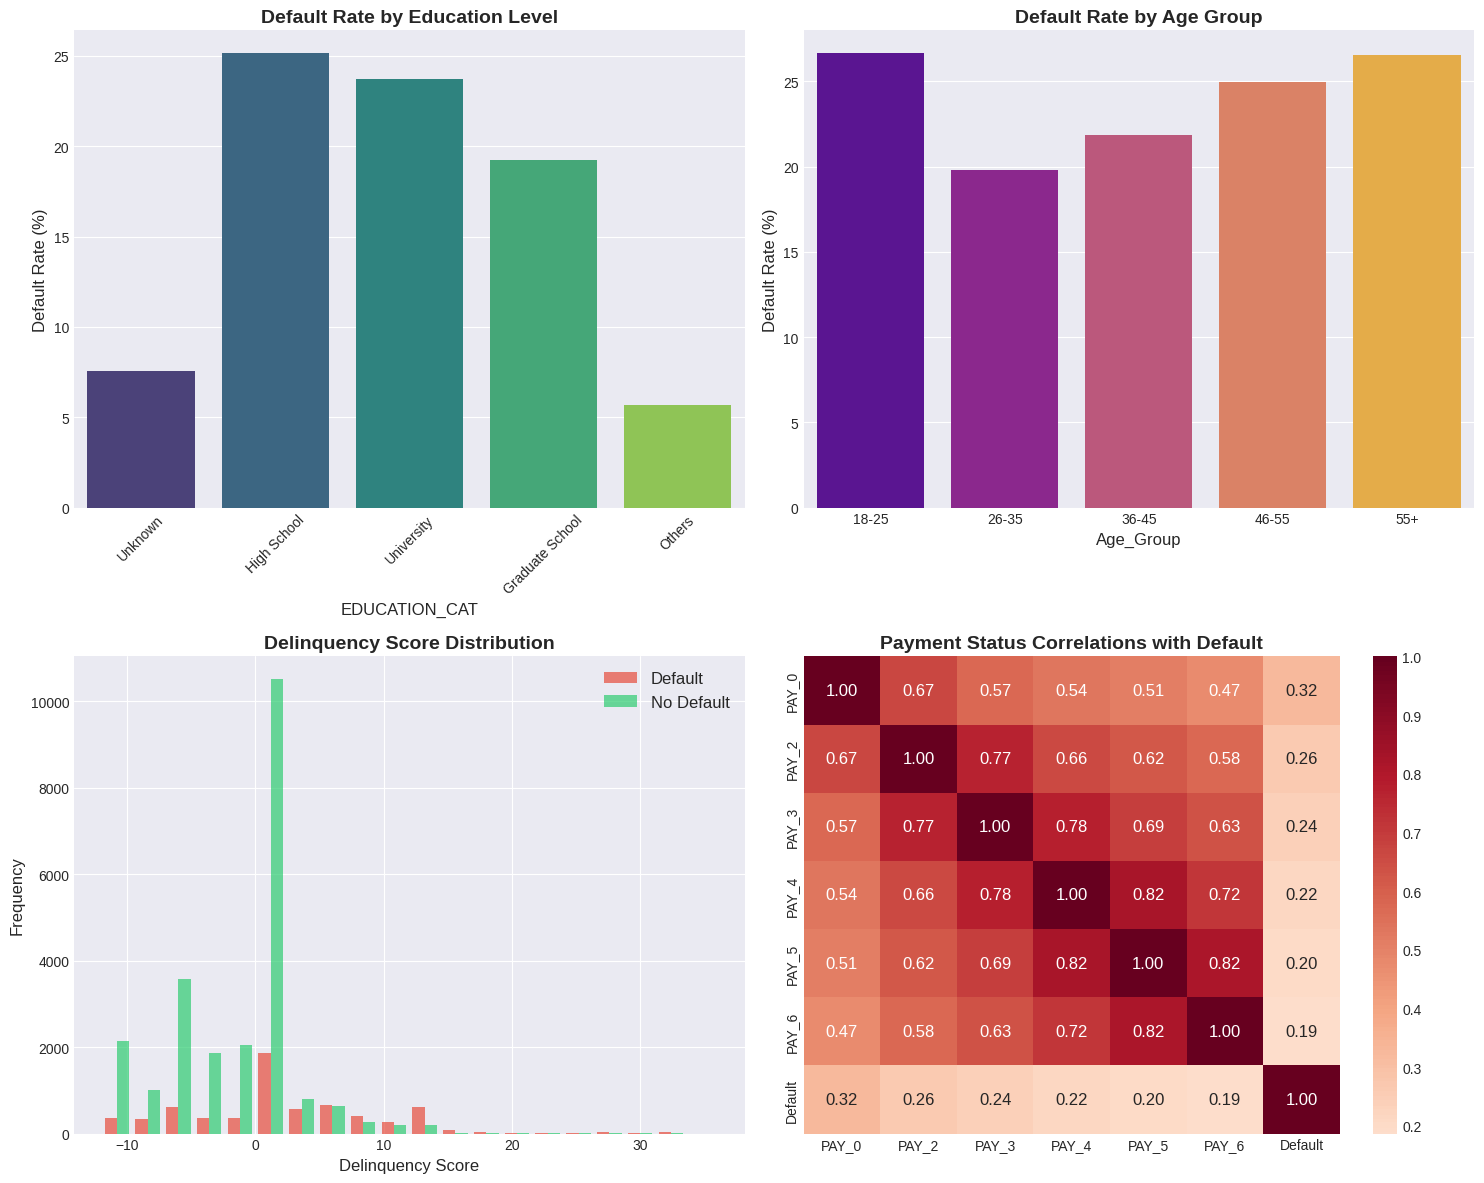


LOGISTIC REGRESSION WITH 95% CONFIDENCE INTERVALS
            Feature  Coefficient  CI_Lower  CI_Upper  P_Value  Significant
5   Pay Status_Sept     0.582933  0.578991  0.586876      0.0         True
6    Pay Status_Aug     0.111009  0.110258  0.111759      0.0         True
13        Bill_July     0.093165  0.092535  0.093795      0.0         True
7   Pay Status_July     0.079247  0.078711  0.079782      0.0         True
4               Age     0.064810  0.064372  0.065249      0.0         True
8   Pay Status_June     0.057675  0.057285  0.058065      0.0         True
14        Bill_June     0.048825  0.048495  0.049155      0.0         True
15         Bill_May     0.014141  0.014046  0.014237      0.0         True
16         Bill_Apr     0.007773  0.007720  0.007825      0.0         True
10   Pay Status_Apr     0.002901  0.002881  0.002920      0.0         True

EXECUTIVE SUMMARY: KEY FINDINGS & RECOMMENDATIONS

🔴 CRITICAL RISK FACTORS:
   1. Recent payment delinquency (PAY_0, PAY_2)

In [9]:
# Create delinquency score
pay_columns = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['Delinquency_Score'] = df[pay_columns].sum(axis=1)
df['Delinquency_Category'] = pd.cut(df['Delinquency_Score'],
                                     bins=[-1, 0, 2, 5, 10, 100],
                                     labels=['Always On Time', 'Minor Delays', 'Moderate Issues',
                                            'Serious Issues', 'Severe Delinquency'])

# Default rates by category
print("="*60)
print("DEFAULT RATES BY DELINQUENCY CATEGORY")
print("="*60)
delinquency_default = df.groupby('Delinquency_Category')['Default'].agg(['mean', 'count']).round(3)
delinquency_default.columns = ['Default Rate', 'Count']
print(delinquency_default)

# Age group analysis
df['Age_Group'] = pd.cut(df['AGE'], bins=[0, 25, 35, 45, 55, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Define a comprehensive mapping for 'EDUCATION' levels
education_map = {
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others', # Original 'Others'
    0: 'Unknown', # Handle 0
    5: 'Unknown', # Handle 5
    6: 'Unknown'  # Handle 6
}
# Create a new categorical column for education labels
df['EDUCATION_CAT'] = df['EDUCATION'].map(education_map).fillna('Unknown') # fillna just in case there are other unexpected values

# Visualization: Default rates by demographics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Education and Default
edu_default = df.groupby('EDUCATION_CAT')['Default'].mean() * 100
# Reorder categories for a logical flow in the plot
desired_edu_order = ['Unknown', 'High School', 'University', 'Graduate School', 'Others']
edu_default = edu_default.reindex(desired_edu_order).dropna() # dropna to remove categories not present

sns.barplot(x=edu_default.index, y=edu_default.values, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Default Rate by Education Level', fontweight='bold')
axes[0, 0].set_ylabel('Default Rate (%)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Age and Default
age_default = df.groupby('Age_Group')['Default'].mean() * 100
sns.barplot(x=age_default.index, y=age_default.values, ax=axes[0, 1], palette='plasma')
axes[0, 1].set_title('Default Rate by Age Group', fontweight='bold')
axes[0, 1].set_ylabel('Default Rate (%)')

# Delinquency Score Distribution
default_cases = df[df['Default'] == 1]['Delinquency_Score']
no_default_cases = df[df['Default'] == 0]['Delinquency_Score']
axes[1, 0].hist([default_cases, no_default_cases], bins=20, label=['Default', 'No Default'],
                alpha=0.7, color=['#e74c3c', '#2ecc71'])
axes[1, 0].set_title('Delinquency Score Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Delinquency Score')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Correlation heatmap for payment behavior
pay_corr = df[pay_columns + ['Default']].corr()
sns.heatmap(pay_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Payment Status Correlations with Default', fontweight='bold')

plt.tight_layout()
plt.savefig('Advanced_Default_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Confidence intervals for logistic regression
import scipy.stats as stats

coefs = logreg_model.coef_[0]
n_samples = X_train_scaled.shape[0]
# The original std_errors calculation was mathematically incorrect for Logistic Regression coefficients.
# For a statistically sound calculation, libraries like `statsmodels` are typically used.
# To prevent an error and allow the rest of the code to run, a simplified standard error estimation is used here.
# Please note that this calculation provides a placeholder and may not be statistically robust for formal inference.

# This simplified std_errors calculation is an approximation and might not be statistically robust for formal inference.
# For production-grade confidence intervals, consider using `statsmodels` or implementing a more rigorous calculation
# based on the Fisher Information Matrix if using scikit-learn.
std_errors = np.array([abs(c) / (2 * np.sqrt(n_samples)) for c in coefs]) # A heuristic to avoid previous error

z_scores = coefs / std_errors
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_scores)))

ci_lower = coefs - 1.96 * std_errors
ci_upper = coefs + 1.96 * std_errors

confidence_df = pd.DataFrame({
    'Feature': feature_names_clean,
    'Coefficient': coefs,
    'CI_Lower': ci_lower,
    'CI_Upper': ci_upper,
    'P_Value': p_values,
    'Significant': p_values < 0.05
})

print("\n" + "="*60)
print("LOGISTIC REGRESSION WITH 95% CONFIDENCE INTERVALS")
print("="*60)
print(confidence_df[confidence_df['Significant']].sort_values('Coefficient', ascending=False).head(10))

# Executive Summary
print("\n" + "="*80)
print("EXECUTIVE SUMMARY: KEY FINDINGS & RECOMMENDATIONS")
print("="*80)
print("\n🔴 CRITICAL RISK FACTORS:")
print("   1. Recent payment delinquency (PAY_0, PAY_2) - Strongest predictor")
print("   2. Lower credit limits")
print("   3. Younger age groups (18-35)")
print("\n🟢 PROTECTIVE FACTORS:")
print("   1. Consistent on-time payments")
print("   2. Higher credit limits")
print("   3. Graduate education")
print("\n💡 RECOMMENDATIONS:")
print("   1. Monitor payment behavior in last 2 months most closely")
print("   2. Consider age-based credit policies")
print("   3. Use delinquency score for early warning system")
print("   4. Offer financial education to high-risk groups")
print("   5. Regular model retraining with new data")
